# Vehicle Detection with HOG + SVM and Background Modelling

This notebook implements a vehicle detection system using HOG (Histogram of Oriented Gradients) feature extraction combined with a Linear SVM classifier. The dataset contains three classes — `car`, `motorcycle`, and `background` — where the first two are merged into a single positive class (`vehicle`) and `background` serves as the negative class.

**Pipeline Overview:**
1. Environment Setup
2. Dataset Download and Extraction
3. Data Preparation and Splitting
4. Exploratory Data Analysis and Visualization
5. HOG Feature Extraction
6. Model Training
7. Model Evaluation
8. Error Analysis
9. Model Saving
10. Summary and Conclusions

---
## 1. Environment Setup

In [ ]:
# Install required dependencies
!pip install gdown opencv-python scikit-learn scikit-image matplotlib seaborn numpy pandas joblib tqdm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 6.5 MB/s eta 0:00:00


In [ ]:
import os
import random
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
import joblib
import gdown

from pathlib import Path
from tqdm import tqdm
from skimage.feature import hog
from skimage import exposure
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings('ignore')

# Global configuration
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# HOG Parameters
HOG_PARAMS = {
    'window_size': (64, 128),   # (width, height)
    'pixels_per_cell': (8, 8),
    'cells_per_block': (2, 2),
    'orientations': 9,
}

# Paths
DATASET_DIR = Path('raw')
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

# Plot style
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('All libraries imported successfully.')
print(f'Random seed set to: {RANDOM_SEED}')

All libraries imported successfully.
Random seed set to: 42


---
## 2. Dataset Download and Extraction

In [ ]:
GDRIVE_FILE_ID = '1klbZpEcyAxNBimXSPmmi2qRFI4g0mA_U'
ZIP_PATH = 'dataset.zip'

if not Path(ZIP_PATH).exists():
    print('Downloading dataset from Google Drive...')
    gdown.download(id=GDRIVE_FILE_ID, output=ZIP_PATH, quiet=False)
else:
    print(f'Dataset archive already exists at: {ZIP_PATH}')

if not DATASET_DIR.exists():
    print('Extracting dataset...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        members = zf.namelist()
        for member in tqdm(members, desc='Extracting', unit='file'):
            zf.extract(member, '.')
    print('Extraction complete.')
else:
    print(f'Dataset directory already exists at: {DATASET_DIR}')

Downloading...
From (original): https://drive.google.com/uc?id=1klbZpEcyAxNBimXSPmmi2qRFI4g0mA_U
From (redirected): https://drive.google.com/uc?id=1klbZpEcyAxNBimXSPmmi2qRFI4g0mA_U&confirm=t&uuid=1946f373-5bcc-4e6c-8c50-41546eb7a01e
To: /content/dataset.zip
100%|██████████| 1.96G/1.96G [00:12<00:00, 161MB/s]


Extracting dataset...


Extracting: 100%|██████████| 436689/436689 [00:48<00:00, 9024.18file/s]

Extraction complete.


In [ ]:
# Verify directory structure and count files
CLASSES = ['background', 'car', 'motorcycle']

print('Dataset structure:')
for cls in CLASSES:
    cls_dir = DATASET_DIR / cls
    if cls_dir.exists():
        count = len(list(cls_dir.glob('*.*')))
        print(f'  {cls_dir}/ -> {count:,} images')
    else:
        print(f'  WARNING: {cls_dir}/ not found')

Dataset structure:
  raw/background/ -> 160,000 images
  raw/car/ -> 260,518 images
  raw/motorcycle/ -> 16,167 images


---
## 3. Data Preparation and Splitting

In [ ]:
from sklearn.model_selection import train_test_split

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

records = []

for cls in CLASSES:
    cls_dir = DATASET_DIR / cls
    label = 0 if cls == 'background' else 1  # 0=background, 1=vehicle
    for img_path in cls_dir.glob('*.*'):
        records.append({
            'path': str(img_path),
            'original_class': cls,
            'label': label
        })

df = pd.DataFrame(records)
print(f'Total images: {len(df):,}')
print(df['original_class'].value_counts())

# Split: stratify by label to maintain class balance
df_train, df_temp = train_test_split(
    df, test_size=(VAL_RATIO + TEST_RATIO),
    stratify=df['label'], random_state=RANDOM_SEED
)
df_val, df_test = train_test_split(
    df_temp, test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    stratify=df_temp['label'], random_state=RANDOM_SEED
)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f'\nSplit sizes:')
print(f'  Train : {len(df_train):,}')
print(f'  Val   : {len(df_val):,}')
print(f'  Test  : {len(df_test):,}')

print('\nClass distribution per split:')
for name, split in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    vc = split['label'].value_counts().rename({0: 'background', 1: 'vehicle'})
    print(f'  {name}: {vc.to_dict()}')

Total images: 436,685
original_class
car           260518
background    160000
motorcycle     16167
Name: count, dtype: int64

Split sizes:
  Train : 305,679
  Val   : 65,503
  Test  : 65,503

Class distribution per split:
  Train: {'vehicle': 193679, 'background': 112000}
  Val: {'vehicle': 41503, 'background': 24000}
  Test: {'vehicle': 41503, 'background': 24000}


---
## 4. Exploratory Data Analysis and Visualization

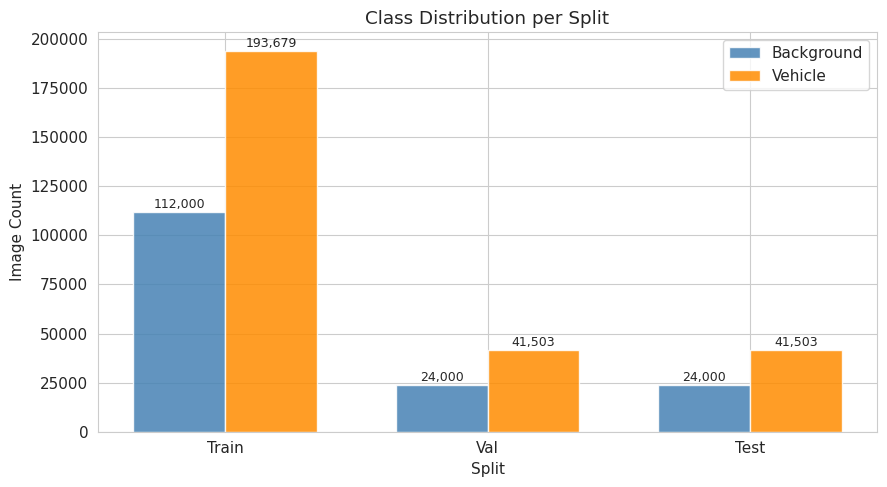

Saved: outputs/class_distribution.png


In [ ]:
# --- Class Distribution per Split ---
split_names = ['Train', 'Val', 'Test']
split_dfs   = [df_train, df_val, df_test]

dist_data = []
for name, split in zip(split_names, split_dfs):
    for label_val, label_name in [(0, 'Background'), (1, 'Vehicle')]:
        dist_data.append({
            'Split': name,
            'Class': label_name,
            'Count': (split['label'] == label_val).sum()
        })

dist_df = pd.DataFrame(dist_data)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(split_names))
width = 0.35
bg_counts  = dist_df[dist_df['Class'] == 'Background']['Count'].values
veh_counts = dist_df[dist_df['Class'] == 'Vehicle']['Count'].values

bars1 = ax.bar(x - width/2, bg_counts,  width, label='Background', color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + width/2, veh_counts, width, label='Vehicle',    color='darkorange', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(split_names)
ax.set_xlabel('Split')
ax.set_ylabel('Image Count')
ax.set_title('Class Distribution per Split')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=150)
plt.show()
print('Saved: outputs/class_distribution.png')

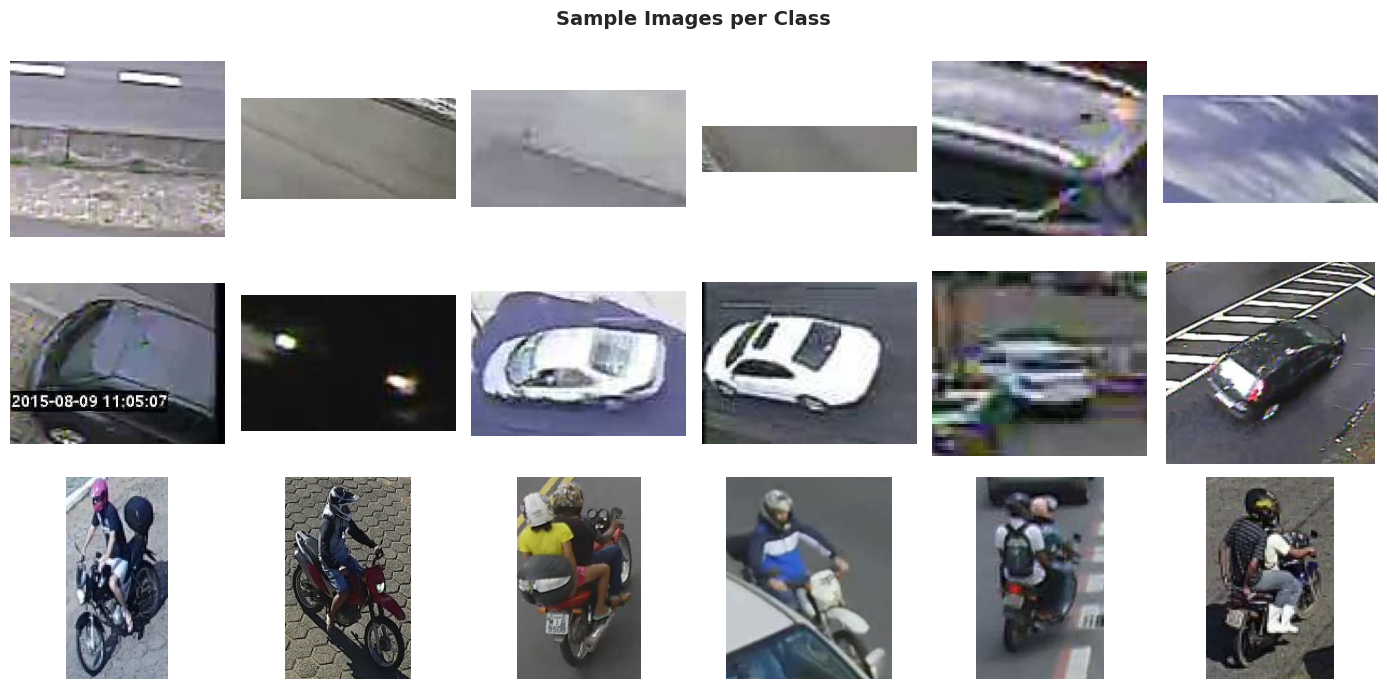

Saved: outputs/sample_grid.png


In [ ]:
# --- Sample Image Grid per Original Class ---
SAMPLES_PER_CLASS = 6
fig, axes = plt.subplots(len(CLASSES), SAMPLES_PER_CLASS, figsize=(14, 7))

for row_idx, cls in enumerate(CLASSES):
    cls_paths = df[df['original_class'] == cls]['path'].sample(
        n=SAMPLES_PER_CLASS, random_state=RANDOM_SEED
    ).values
    for col_idx, img_path in enumerate(cls_paths):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis('off')
        if col_idx == 0:
            axes[row_idx, col_idx].set_ylabel(cls.capitalize(), fontsize=12, fontweight='bold')

fig.suptitle('Sample Images per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_grid.png', dpi=150)
plt.show()
print('Saved: outputs/sample_grid.png')

Reading image sizes: 100%|██████████| 3000/3000 [00:00<00:00, 9020.47img/s]


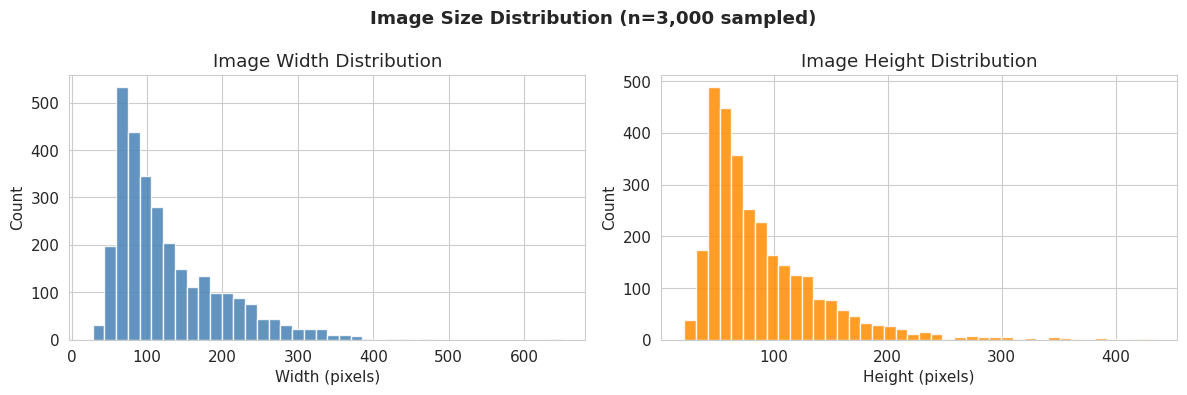

Saved: outputs/image_size_distribution.png
Width  -> mean: 126.5, median: 103.0
Height -> mean: 90.1, median: 73.0


In [ ]:
# --- Image Size Distribution (sampled for speed) ---
SAMPLE_N = min(3000, len(df))
sampled_paths = df['path'].sample(n=SAMPLE_N, random_state=RANDOM_SEED).values

heights, widths = [], []
for p in tqdm(sampled_paths, desc='Reading image sizes', unit='img'):
    img = cv2.imread(p)
    if img is not None:
        h, w = img.shape[:2]
        heights.append(h)
        widths.append(w)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths,  bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Count')

axes[1].hist(heights, bins=40, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Count')

fig.suptitle(f'Image Size Distribution (n={SAMPLE_N:,} sampled)', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'image_size_distribution.png', dpi=150)
plt.show()
print('Saved: outputs/image_size_distribution.png')
print(f'Width  -> mean: {np.mean(widths):.1f}, median: {np.median(widths):.1f}')
print(f'Height -> mean: {np.mean(heights):.1f}, median: {np.median(heights):.1f}')

---
## 5. HOG Feature Extraction

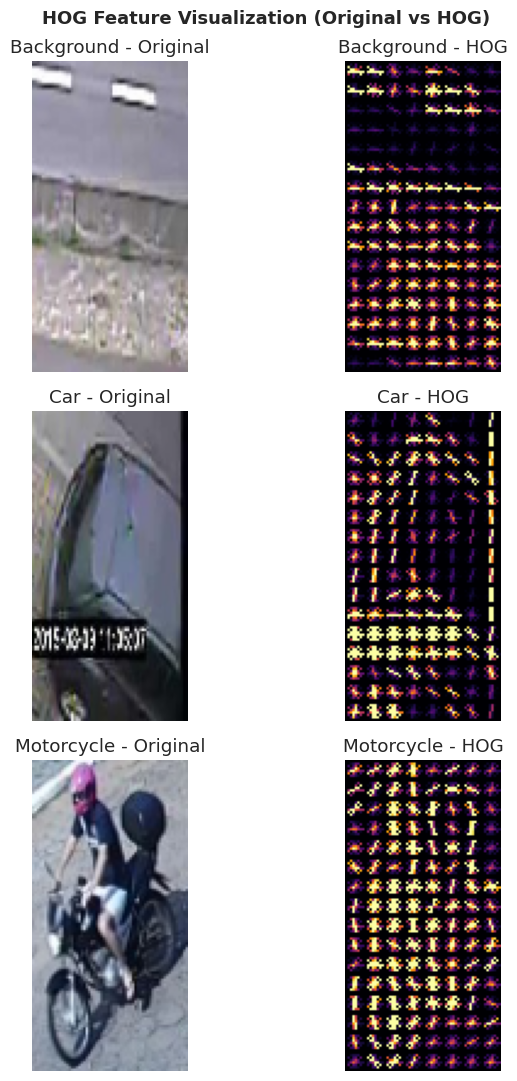

Saved: outputs/hog_visualization.png


In [ ]:
# --- HOG Visualization: one sample per original class ---
WIN_W, WIN_H = HOG_PARAMS['window_size']

fig, axes = plt.subplots(len(CLASSES), 2, figsize=(8, 11))
fig.suptitle('HOG Feature Visualization (Original vs HOG)', fontsize=13, fontweight='bold')

for row_idx, cls in enumerate(CLASSES):
    sample_path = df[df['original_class'] == cls]['path'].sample(
        n=1, random_state=RANDOM_SEED
    ).values[0]
    img = cv2.imread(sample_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img_gray, (WIN_W, WIN_H))

    _, hog_image = hog(
        img_resized,
        orientations=HOG_PARAMS['orientations'],
        pixels_per_cell=HOG_PARAMS['pixels_per_cell'],
        cells_per_block=HOG_PARAMS['cells_per_block'],
        visualize=True,
        feature_vector=True
    )
    hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

    img_rgb_resized = cv2.resize(
        cv2.cvtColor(img, cv2.COLOR_BGR2RGB), (WIN_W, WIN_H)
    )
    axes[row_idx, 0].imshow(img_rgb_resized)
    axes[row_idx, 0].set_title(f'{cls.capitalize()} - Original')
    axes[row_idx, 0].axis('off')

    axes[row_idx, 1].imshow(hog_image_rescaled, cmap='inferno')
    axes[row_idx, 1].set_title(f'{cls.capitalize()} - HOG')
    axes[row_idx, 1].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hog_visualization.png', dpi=150)
plt.show()
print('Saved: outputs/hog_visualization.png')

In [ ]:
def extract_hog_features(img_path: str) -> np.ndarray | None:
    """Load an image, resize it, and extract HOG features."""
    img = cv2.imread(img_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, HOG_PARAMS['window_size'])  # (W, H)
    features = hog(
        resized,
        orientations=HOG_PARAMS['orientations'],
        pixels_per_cell=HOG_PARAMS['pixels_per_cell'],
        cells_per_block=HOG_PARAMS['cells_per_block'],
        visualize=False,
        feature_vector=True
    )
    return features


def extract_features_for_split(
    df_split: pd.DataFrame, split_name: str
) -> tuple[np.ndarray, np.ndarray]:
    """Extract HOG features for all images in a DataFrame split."""
    features, labels = [], []
    for _, row in tqdm(
        df_split.iterrows(),
        total=len(df_split),
        desc=f'Extracting HOG [{split_name}]',
        unit='img'
    ):
        feat = extract_hog_features(row['path'])
        if feat is not None:
            features.append(feat)
            labels.append(row['label'])
    return np.array(features), np.array(labels)

In [ ]:
print('Extracting HOG features for all splits...')
print('(This may take several minutes depending on dataset size)')

X_train, y_train = extract_features_for_split(df_train, 'Train')
X_val,   y_val   = extract_features_for_split(df_val,   'Val')
X_test,  y_test  = extract_features_for_split(df_test,  'Test')

print(f'\nFeature shapes:')
print(f'  X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'  X_val  : {X_val.shape},   y_val  : {y_val.shape}')
print(f'  X_test : {X_test.shape},  y_test : {y_test.shape}')
print(f'\nHOG feature vector length: {X_train.shape[1]}')

Extracting HOG features for all splits...
(This may take several minutes depending on dataset size)


Extracting HOG [Test]: 100%|██████████| 65503/65503 [02:45<00:00, 396.06img/s]



Feature shapes:
  X_train: (305679, 3780), y_train: (305679,)
  X_val  : (65503, 3780),   y_val  : (65503,)
  X_test : (65503, 3780),  y_test : (65503,)

HOG feature vector length: 3780


---
## 6. Model Training

In [ ]:
# Feature scaling — fit only on training data
print('Fitting StandardScaler on training data...')
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print('Scaling complete.')

Fitting StandardScaler on training data...
Scaling complete.


In [ ]:
from sklearn.linear_model import SGDClassifier
import gc

base_svm = SGDClassifier(
    loss='hinge',
    class_weight='balanced',
    random_state=RANDOM_SEED,
    max_iter=100,
    tol=1e-3,
    n_jobs=-1
)

svm_model = CalibratedClassifierCV(base_svm, cv=2)
svm_model.fit(X_train_scaled, y_train)
print('Training complete.')

# Validate on validation set
y_val_pred = svm_model.predict(X_val_scaled)
val_acc = accuracy_score(y_val, y_val_pred)
print(f'\nValidation Accuracy: {val_acc:.4f}')
print('\nValidation Classification Report:')
print(classification_report(
    y_val, y_val_pred,
    target_names=['Background', 'Vehicle']
))

# Bebaskan memory setelah validasi selesai
del X_val, X_val_scaled
gc.collect()

Training complete.

Validation Accuracy: 0.9549

Validation Classification Report:
              precision    recall  f1-score   support

  Background       0.95      0.93      0.94     24000
     Vehicle       0.96      0.97      0.96     41503

    accuracy                           0.95     65503
   macro avg       0.95      0.95      0.95     65503
weighted avg       0.95      0.95      0.95     65503



35284

---
## 7. Model Evaluation

In [ ]:
# Evaluate on held-out test set
y_test_pred  = svm_model.predict(X_test_scaled)
y_test_proba = svm_model.predict_proba(X_test_scaled)[:, 1]  # probability for class 'vehicle'

acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec  = recall_score(y_test, y_test_pred)
f1   = f1_score(y_test, y_test_pred)

print('=' * 45)
print('       TEST SET PERFORMANCE METRICS')
print('=' * 45)
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print('=' * 45)
print('\nFull Classification Report:')
print(classification_report(
    y_test, y_test_pred,
    target_names=['Background', 'Vehicle']
))

       TEST SET PERFORMANCE METRICS
  Accuracy  : 0.9543
  Precision : 0.9589
  Recall    : 0.9694
  F1-Score  : 0.9641

Full Classification Report:
              precision    recall  f1-score   support

  Background       0.95      0.93      0.94     24000
     Vehicle       0.96      0.97      0.96     41503

    accuracy                           0.95     65503
   macro avg       0.95      0.95      0.95     65503
weighted avg       0.95      0.95      0.95     65503



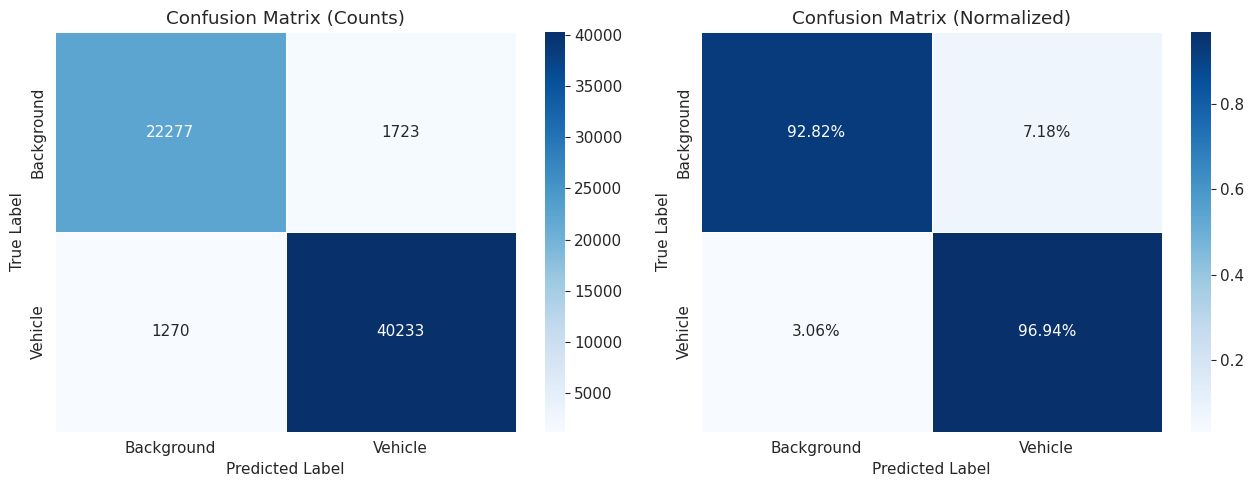

Saved: outputs/confusion_matrix.png


In [ ]:
# --- Confusion Matrix Heatmap ---
cm = confusion_matrix(y_test, y_test_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Background', 'Vehicle'],
    yticklabels=['Background', 'Vehicle'],
    ax=axes[0], linewidths=0.5
)
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Normalized
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Blues',
    xticklabels=['Background', 'Vehicle'],
    yticklabels=['Background', 'Vehicle'],
    ax=axes[1], linewidths=0.5
)
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150)
plt.show()
print('Saved: outputs/confusion_matrix.png')

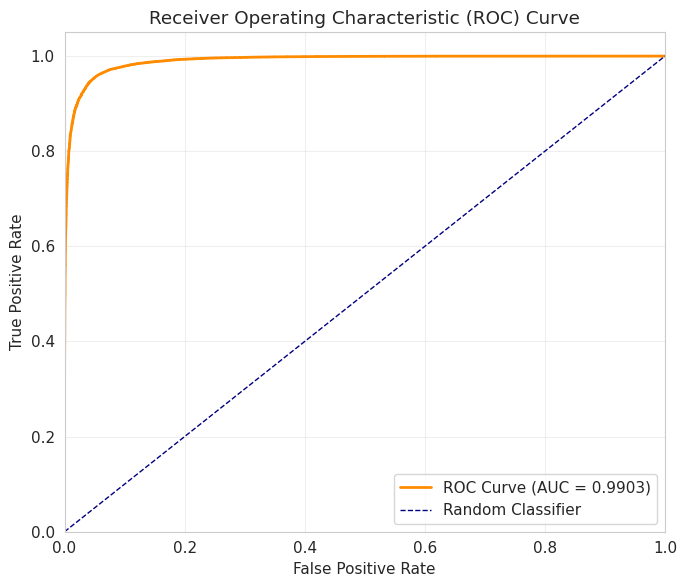

AUC Score: 0.9903
Saved: outputs/roc_curve.png


In [ ]:
# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2,
        label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Receiver Operating Characteristic (ROC) Curve')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curve.png', dpi=150)
plt.show()
print(f'AUC Score: {roc_auc:.4f}')
print('Saved: outputs/roc_curve.png')

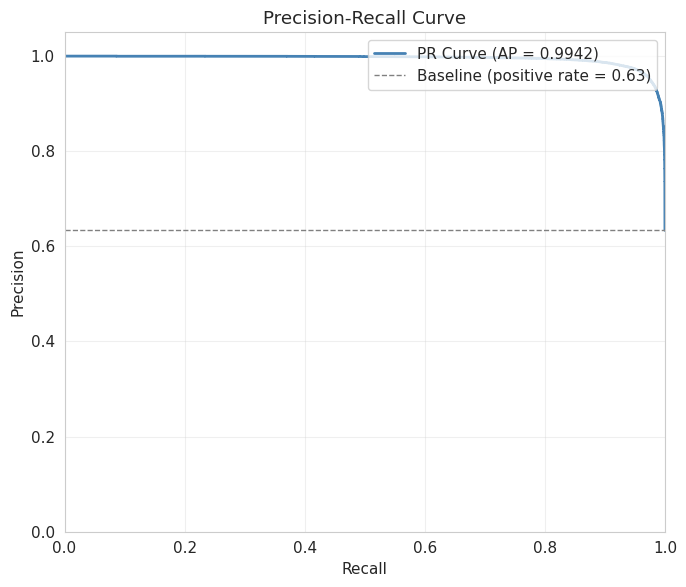

Average Precision (AP): 0.9942
Saved: outputs/pr_curve.png


In [ ]:
# --- Precision-Recall Curve ---
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_test_proba)
avg_precision = average_precision_score(y_test, y_test_proba)
baseline = y_test.sum() / len(y_test)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recall_vals, precision_vals, color='steelblue', lw=2,
        label=f'PR Curve (AP = {avg_precision:.4f})')
ax.axhline(y=baseline, color='gray', linestyle='--', lw=1,
           label=f'Baseline (positive rate = {baseline:.2f})')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pr_curve.png', dpi=150)
plt.show()
print(f'Average Precision (AP): {avg_precision:.4f}')
print('Saved: outputs/pr_curve.png')

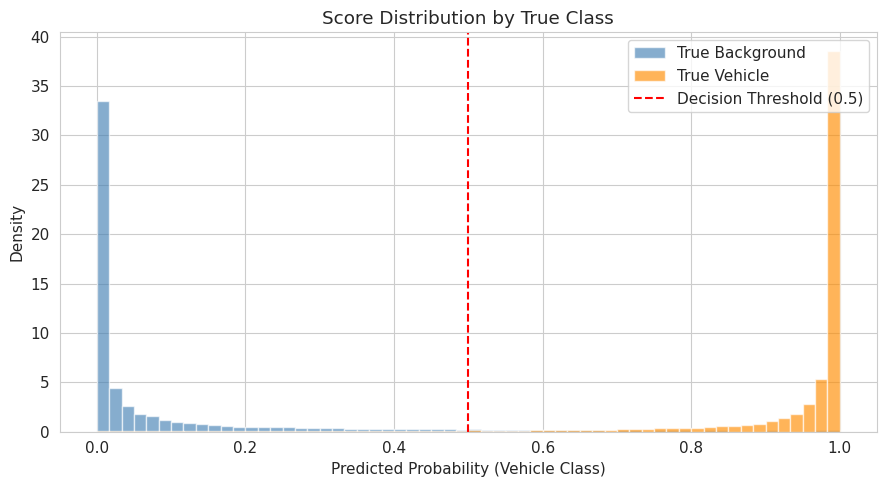

Saved: outputs/score_distribution.png


In [ ]:
# --- Score Distribution Heatmap ---
# Shows the distribution of predicted probabilities per true class
fig, ax = plt.subplots(figsize=(9, 5))

scores_bg  = y_test_proba[y_test == 0]
scores_veh = y_test_proba[y_test == 1]

ax.hist(scores_bg,  bins=60, alpha=0.65, color='steelblue',  label='True Background', density=True)
ax.hist(scores_veh, bins=60, alpha=0.65, color='darkorange', label='True Vehicle',    density=True)
ax.axvline(x=0.5, color='red', linestyle='--', lw=1.5, label='Decision Threshold (0.5)')
ax.set_xlabel('Predicted Probability (Vehicle Class)')
ax.set_ylabel('Density')
ax.set_title('Score Distribution by True Class')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'score_distribution.png', dpi=150)
plt.show()
print('Saved: outputs/score_distribution.png')

---
## 8. Error Analysis

In [ ]:
# Build error DataFrame
df_test_eval = df_test.iloc[:len(y_test)].copy().reset_index(drop=True)
df_test_eval['y_pred']      = y_test_pred
df_test_eval['y_proba']     = y_test_proba
df_test_eval['y_true']      = y_test
df_test_eval['correct']     = df_test_eval['y_true'] == df_test_eval['y_pred']

df_errors = df_test_eval[~df_test_eval['correct']].reset_index(drop=True)

false_positives = df_errors[df_errors['y_pred'] == 1]  # bg predicted as vehicle
false_negatives = df_errors[df_errors['y_pred'] == 0]  # vehicle predicted as bg

print('Error Analysis Summary')
print('=' * 40)
print(f'  Total test samples    : {len(df_test_eval):,}')
print(f'  Total misclassified   : {len(df_errors):,}')
print(f'  False Positives (FP)  : {len(false_positives):,}  (bg -> vehicle)')
print(f'  False Negatives (FN)  : {len(false_negatives):,}  (vehicle -> bg)')
print(f'  Error rate            : {len(df_errors)/len(df_test_eval):.2%}')

Error Analysis Summary
  Total test samples    : 65,503
  Total misclassified   : 2,993
  False Positives (FP)  : 1,723  (bg -> vehicle)
  False Negatives (FN)  : 1,270  (vehicle -> bg)
  Error rate            : 4.57%


Saved: outputs/error_false_positives.png


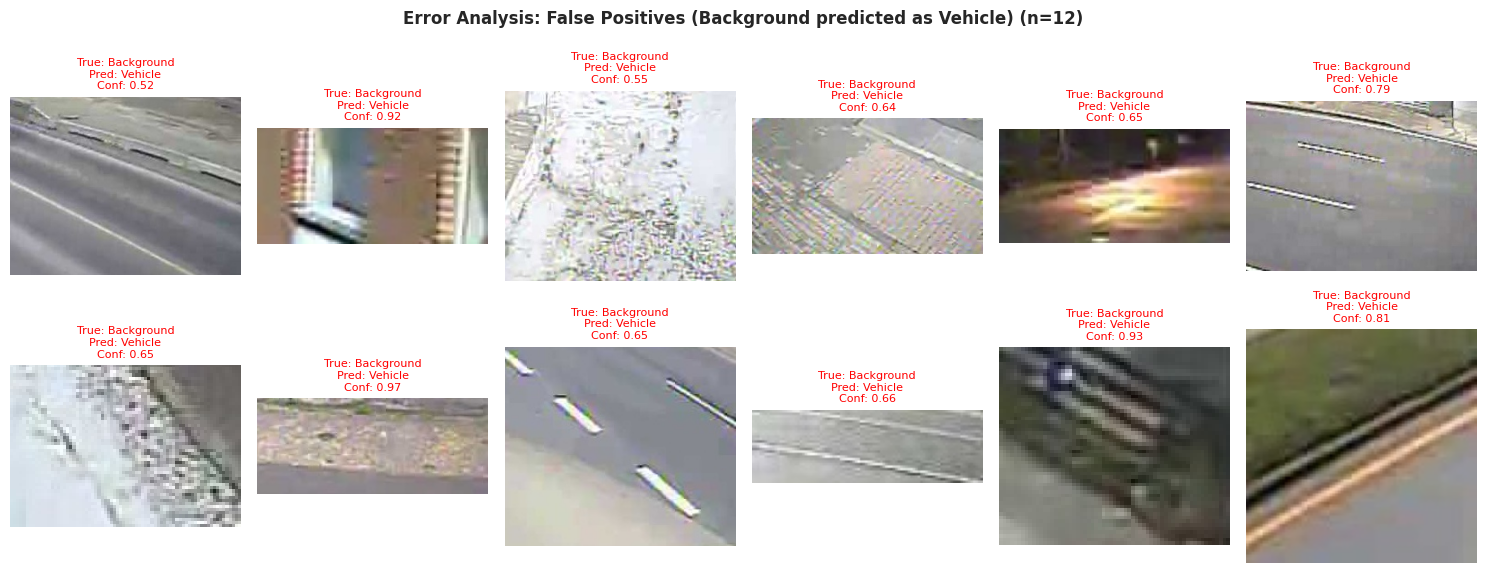

Saved: outputs/error_false_negatives.png


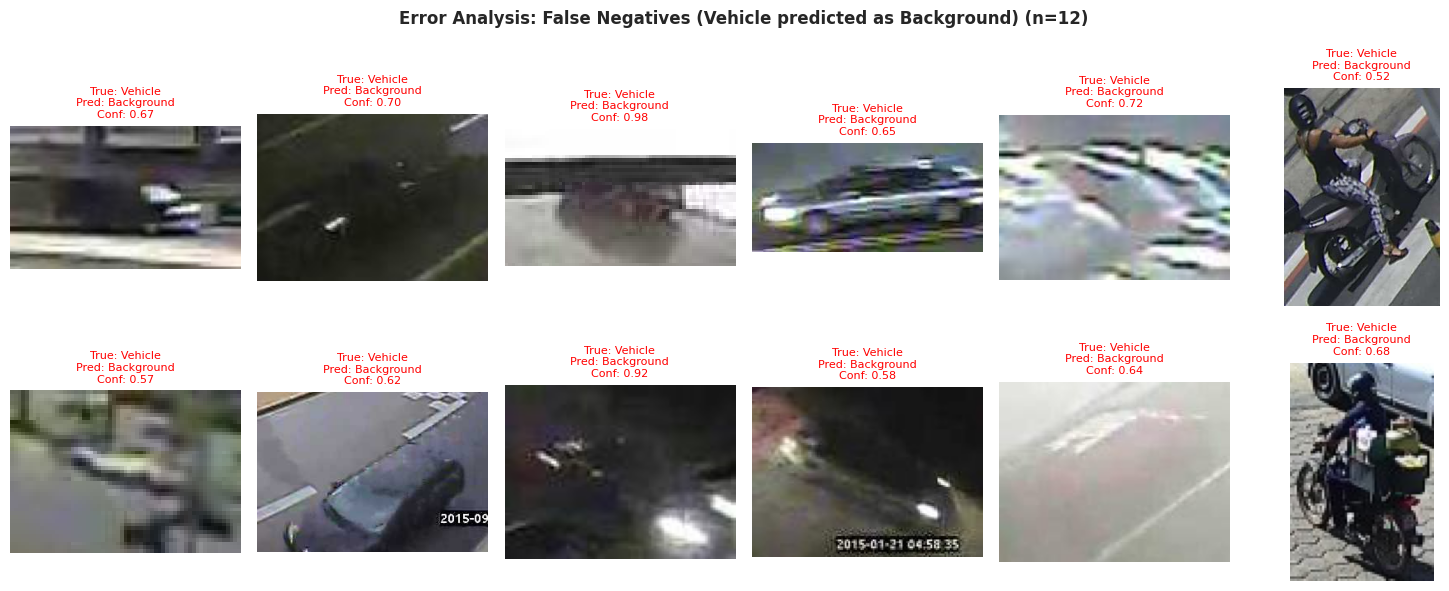

In [ ]:
def plot_error_grid(
    df_err: pd.DataFrame,
    error_type: str,
    n_samples: int = 12,
    save_path: str | None = None
):
    """Display a grid of misclassified images with labels and confidence."""
    sample = df_err.sample(n=min(n_samples, len(df_err)), random_state=RANDOM_SEED)
    cols = 6
    rows = int(np.ceil(len(sample) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 3))
    axes = axes.flatten()

    for i, (_, row) in enumerate(sample.iterrows()):
        img = cv2.imread(row['path'])
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        true_name = 'Vehicle'    if row['y_true'] == 1 else 'Background'
        pred_name = 'Vehicle'    if row['y_pred'] == 1 else 'Background'
        conf      = row['y_proba'] if row['y_pred'] == 1 else 1 - row['y_proba']
        axes[i].set_title(
            f'True: {true_name}\nPred: {pred_name}\nConf: {conf:.2f}',
            fontsize=8, color='red'
        )
        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'Error Analysis: {error_type} (n={len(sample)})', fontsize=12, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f'Saved: {save_path}')
    plt.show()


if len(false_positives) > 0:
    plot_error_grid(
        false_positives, 'False Positives (Background predicted as Vehicle)',
        save_path=str(OUTPUT_DIR / 'error_false_positives.png')
    )

if len(false_negatives) > 0:
    plot_error_grid(
        false_negatives, 'False Negatives (Vehicle predicted as Background)',
        save_path=str(OUTPUT_DIR / 'error_false_negatives.png')
    )

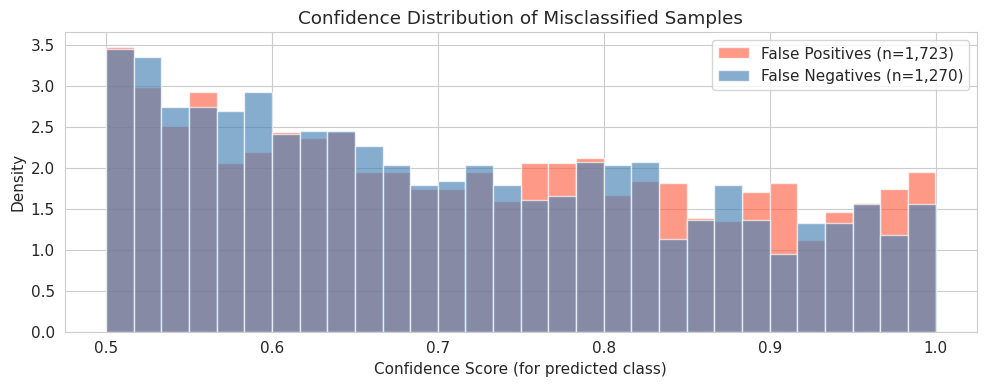

Saved: outputs/error_confidence_distribution.png


In [ ]:
# --- Confidence Distribution for Errors (heatmap style) ---
if len(df_errors) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))

    fp_conf = false_positives['y_proba'].values
    fn_conf = (1 - false_negatives['y_proba'].values) if len(false_negatives) > 0 else np.array([])

    if len(fp_conf) > 0:
        ax.hist(fp_conf, bins=30, alpha=0.65, color='tomato',
                label=f'False Positives (n={len(fp_conf):,})', density=True)
    if len(fn_conf) > 0:
        ax.hist(fn_conf, bins=30, alpha=0.65, color='steelblue',
                label=f'False Negatives (n={len(fn_conf):,})', density=True)

    ax.set_xlabel('Confidence Score (for predicted class)')
    ax.set_ylabel('Density')
    ax.set_title('Confidence Distribution of Misclassified Samples')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'error_confidence_distribution.png', dpi=150)
    plt.show()
    print('Saved: outputs/error_confidence_distribution.png')

---
## 9. Model Saving

In [ ]:
# Save trained model, scaler, and HOG config
MODEL_PATH  = OUTPUT_DIR / 'svm_model.joblib'
SCALER_PATH = OUTPUT_DIR / 'scaler.joblib'
CONFIG_PATH = OUTPUT_DIR / 'hog_config.joblib'

joblib.dump(svm_model,   MODEL_PATH)
joblib.dump(scaler,      SCALER_PATH)
joblib.dump(HOG_PARAMS,  CONFIG_PATH)

print('Model artifacts saved:')
print(f'  SVM Model    : {MODEL_PATH}')
print(f'  Scaler       : {SCALER_PATH}')
print(f'  HOG Config   : {CONFIG_PATH}')

# Verify reload
loaded_model  = joblib.load(MODEL_PATH)
loaded_scaler = joblib.load(SCALER_PATH)
reloaded_pred = loaded_model.predict(loaded_scaler.transform(X_test[:5]))
print(f'\nReload verification - predictions on first 5 test samples: {reloaded_pred}')

Model artifacts saved:
  SVM Model    : outputs/svm_model.joblib
  Scaler       : outputs/scaler.joblib
  HOG Config   : outputs/hog_config.joblib

Reload verification - predictions on first 5 test samples: [0 0 1 0 1]


---
## 10. Summary and Conclusions

In [ ]:
print('=' * 55)
print('         EXPERIMENT SUMMARY')
print('=' * 55)

print('\nDataset Statistics:')
for cls in CLASSES:
    count = (df['original_class'] == cls).sum()
    print(f'  {cls.capitalize():<15}: {count:>8,} images')
print(f'  {"Total":<15}: {len(df):>8,} images')

print('\nSplit Sizes:')
print(f'  Train : {len(df_train):,}')
print(f'  Val   : {len(df_val):,}')
print(f'  Test  : {len(df_test):,}')

print('\nHOG Configuration:')
for k, v in HOG_PARAMS.items():
    print(f'  {k:<20}: {v}')
print(f'  {"feature_vector_len":<20}: {X_train.shape[1]}')

print('\nModel: Linear SVM (C=0.01, class_weight=balanced)')
print('       Wrapped with CalibratedClassifierCV (cv=3)')

print('\nTest Set Results:')
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  ROC AUC   : {roc_auc:.4f}')
print(f'  Avg Prec  : {avg_precision:.4f}')

print('\nError Analysis:')
print(f'  Total misclassified : {len(df_errors):,} / {len(df_test_eval):,}')
print(f'  False Positives     : {len(false_positives):,}')
print(f'  False Negatives     : {len(false_negatives):,}')

         EXPERIMENT SUMMARY

Dataset Statistics:
  Background     :  160,000 images
  Car            :  260,518 images
  Motorcycle     :   16,167 images
  Total          :  436,685 images

Split Sizes:
  Train : 305,679
  Val   : 65,503
  Test  : 65,503

HOG Configuration:
  window_size         : (64, 128)
  pixels_per_cell     : (8, 8)
  cells_per_block     : (2, 2)
  orientations        : 9
  feature_vector_len  : 3780

Model: Linear SVM (C=0.01, class_weight=balanced)
       Wrapped with CalibratedClassifierCV (cv=3)

Test Set Results:
  Accuracy  : 0.9543
  Precision : 0.9589
  Recall    : 0.9694
  F1-Score  : 0.9641
  ROC AUC   : 0.9903
  Avg Prec  : 0.9942

Error Analysis:
  Total misclassified : 2,993 / 65,503
  False Positives     : 1,723
  False Negatives     : 1,270


In [ ]:
import cv2
import joblib
import numpy as np
from skimage.feature import hog
from google.colab import files
from tqdm import tqdm

# ── Load model & config ───────────────────────────────────────────────────────
model      = joblib.load(OUTPUT_DIR / 'svm_model.joblib')
scaler     = joblib.load(OUTPUT_DIR / 'scaler.joblib')
hog_params = joblib.load(OUTPUT_DIR / 'hog_config.joblib')
WIN_W, WIN_H = hog_params['window_size']

# ── Predict single patch ──────────────────────────────────────────────────────
def predict_patch(patch):
    gray    = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (WIN_W, WIN_H))
    feat    = hog(
        resized,
        orientations=hog_params['orientations'],
        pixels_per_cell=hog_params['pixels_per_cell'],
        cells_per_block=hog_params['cells_per_block'],
        visualize=False,
        feature_vector=True
    )
    label = model.predict(scaler.transform([feat]))[0]
    proba = model.predict_proba(scaler.transform([feat]))[0][1]
    return label, proba

# ── NMS ───────────────────────────────────────────────────────────────────────
def nms(detections, iou_threshold=0.3):
    if not detections:
        return []
    boxes  = np.array([[x, y, x+w, y+h, p] for x, y, w, h, p in detections])
    x1, y1, x2, y2, scores = boxes[:,0], boxes[:,1], boxes[:,2], boxes[:,3], boxes[:,4]
    areas  = (x2-x1) * (y2-y1)
    order  = scores.argsort()[::-1]
    kept   = []
    while order.size > 0:
        i = order[0]
        kept.append(i)
        xx1   = np.maximum(x1[i], x1[order[1:]])
        yy1   = np.maximum(y1[i], y1[order[1:]])
        xx2   = np.minimum(x2[i], x2[order[1:]])
        yy2   = np.minimum(y2[i], y2[order[1:]])
        inter = np.maximum(0, xx2-xx1) * np.maximum(0, yy2-yy1)
        iou   = inter / (areas[i] + areas[order[1:]] - inter)
        order = order[1:][iou < iou_threshold]
    return [detections[i] for i in kept]

# ── Main inference with background modelling ──────────────────────────────────
def process_video(input_path, output_path,
                  conf_threshold=0.6, iou_threshold=0.3,
                  min_contour_area=500, padding=20):
    cap    = cv2.VideoCapture(input_path)
    fps    = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    out = cv2.VideoWriter(
        output_path,
        cv2.VideoWriter_fourcc(*'mp4v'),
        fps, (width, height)
    )

    # MOG2 background subtractor — learns background over time
    bg_subtractor = cv2.createBackgroundSubtractorMOG2(
        history=500,
        varThreshold=50,
        detectShadows=False
    )

    print(f'Processing {total} frames ({width}x{height} @ {fps:.1f} fps)...')
    for _ in tqdm(range(total), desc='Inference', unit='frame'):
        ret, frame = cap.read()
        if not ret:
            break

        # Step 1: background subtraction -> foreground mask
        fg_mask = bg_subtractor.apply(frame)

        # Step 2: morphological cleanup to remove noise
        kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN,  kernel)
        fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_CLOSE, kernel)

        # Step 3: find contours of moving regions
        contours, _ = cv2.findContours(
            fg_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )

        detections = []
        for cnt in contours:
            if cv2.contourArea(cnt) < min_contour_area:
                continue  # skip tiny noise blobs

            # Bounding box of the moving region + padding
            cx, cy, cw, ch = cv2.boundingRect(cnt)
            x1 = max(cx - padding, 0)
            y1 = max(cy - padding, 0)
            x2 = min(cx + cw + padding, width)
            y2 = min(cy + ch + padding, height)

            patch = frame[y1:y2, x1:x2]
            if patch.size == 0:
                continue

            # Step 4: classify the foreground patch with HOG+SVM
            label, proba = predict_patch(patch)
            if label == 1 and proba >= conf_threshold:
                detections.append((x1, y1, x2-x1, y2-y1, proba))

        # Step 5: NMS to remove overlapping boxes
        detections = nms(detections, iou_threshold=iou_threshold)

        # Draw results
        for x, y, w, h, proba in detections:
            cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(
                frame, f'Vehicle {proba:.2f}',
                (x, max(y-6, 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1
            )

        out.write(frame)

    cap.release()
    out.release()
    print(f'Done. Output saved to: {output_path}')

# ── Upload & run ──────────────────────────────────────────────────────────────
print('Upload your video file:')
uploaded     = files.upload()
input_video  = list(uploaded.keys())[0]

# Change the output extension to .mp4 since cv2.VideoWriter uses 'mp4v'
base_name    = input_video.rsplit('.', 1)[0]
output_video = 'output_' + base_name + '.mp4'

process_video(
    input_path       = input_video,
    output_path      = output_video,
    conf_threshold   = 0.6,
    iou_threshold    = 0.3,
    min_contour_area = 500,
    padding          = 20
)

# This will now find the file correctly
files.download(output_video)

Upload your video file:


Saving WhatsApp Video 2026-05-22 at 20.55.28.mp4 to WhatsApp Video 2026-05-22 at 20.55.28.mp4
Processing 171 frames (848x384 @ 30.7 fps)...


Inference: 100%|██████████| 171/171 [00:02<00:00, 65.38frame/s] 

Done. Output saved to: output_WhatsApp Video 2026-05-22 at 20.55.28.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>